In [2]:
# Import required libraies

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
# Load the dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
# Display the shape of the dataset
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [5]:
# Display the shape of the dataset

print("Dataset Shape:",df.shape)

Dataset Shape: (7043, 21)


In [6]:
# Check column names and data types
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [7]:
# Check for missing values
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [9]:
# Display basic statistical information
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


 DATA CLEANING

In [10]:
# Convert TotalCharges to numeric
# Invalid values such as blank spaces will become NaN

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

 # Check missing values again
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [11]:
# Display records where TotalCharges is missing
missing_total_charges = df[df["TotalCharges"].isnull()]

print(missing_total_charges[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
])

      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           NaN    No
753   3115-CZMZD       0           20.25           NaN    No
936   5709-LVOEQ       0           80.85           NaN    No
1082  4367-NUYAO       0           25.75           NaN    No
1340  1371-DWPAZ       0           56.05           NaN    No
3331  7644-OMVMY       0           19.85           NaN    No
3826  3213-VVOLG       0           25.35           NaN    No
4380  2520-SGTTA       0           20.00           NaN    No
5218  2923-ARZLG       0           19.70           NaN    No
6670  4075-WKNIU       0           73.35           NaN    No
6754  2775-SEFEE       0           61.90           NaN    No


In [13]:
# 11 missing values in TotalCharges, investigating those records rather than immediately deleting them all had tenure of 0,We therefore treated their total charges as 0, which is more logically appropriate than replacing them with the mean or median.

mask = (
    df["TotalCharges"].isna() &
    (df["tenure"] == 0)
)

df.loc[mask, "TotalCharges"] = 0.0

In [14]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [15]:
df.shape

(7043, 21)

In [12]:
# Remove unnecessary whitespace from text columns

object_columns = df.select_dtypes(include=['object']).columns
for col in object_columns:
    df[col] = df[col].str.strip()

In [16]:
# Checking the numerical ranges

print("Negative tenure:", (df["tenure"] < 0).sum())
print("Negative monthly charges:", (df["MonthlyCharges"] < 0).sum())
print("Negative total charges:", (df["TotalCharges"] < 0).sum())


Negative tenure: 0
Negative monthly charges: 0
Negative total charges: 0


In [17]:
# Created a binary column for Churn, where 'Yes' is 1 and 'No' is 0

df["ChurnBinary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
}).astype("int8")

In [20]:
# Created a readable Senior Citizen variable, where 1 is 'Yes' and 0 is 'No'

df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({
    0: "No",
    1: "Yes"
})

In [19]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnBinary,SeniorCitizenLabel
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,No
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,No
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,No
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No,0,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,Month-to-month,No,Mailed check,29.75,301.90,No,0,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,No
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No,0,No


In [21]:
# Final validation of the dataset after cleaning

print("\nFinal dataset shape:", df.shape)

print(
    "\nRemaining missing values:"
)
print(df.isnull().sum().sum())

print(
    "\nDuplicate rows:",
    df.duplicated().sum()
)

print(
    "\nFinal data types:"
)
print(df.dtypes)


Final dataset shape: (7043, 23)

Remaining missing values:
0

Duplicate rows: 0

Final data types:
customerID             object
gender                 object
SeniorCitizen           int64
Partner                object
Dependents             object
tenure                  int64
PhoneService           object
MultipleLines          object
InternetService        object
OnlineSecurity         object
OnlineBackup           object
DeviceProtection       object
TechSupport            object
StreamingTV            object
StreamingMovies        object
Contract               object
PaperlessBilling       object
PaymentMethod          object
MonthlyCharges        float64
TotalCharges          float64
Churn                  object
ChurnBinary              int8
SeniorCitizenLabel     object
dtype: object


Summary Statistics

In [23]:
# Numerical summary
print("Numerical Summary:")
display(df.describe())

# Customer churn counts
print("\nChurn Counts:")
print(df["Churn"].value_counts())

# Calculate churn rate
churn_rate = (df["Churn"] == "Yes").mean() * 100
print(f"\nOverall Churn Rate: {churn_rate:.2f}%")

# Average tenure and charges
print(f"Average Tenure: {df['tenure'].mean():.2f} months")
print(f"Average Monthly Charges: ${df['MonthlyCharges'].mean():.2f}")
print(f"Average Total Charges: ${df['TotalCharges'].mean():.2f}")

Numerical Summary:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnBinary
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000



Churn Counts:
No     5174
Yes    1869
Name: Churn, dtype: int64

Overall Churn Rate: 26.54%
Average Tenure: 32.37 months
Average Monthly Charges: $64.76
Average Total Charges: $2279.73


Visualization

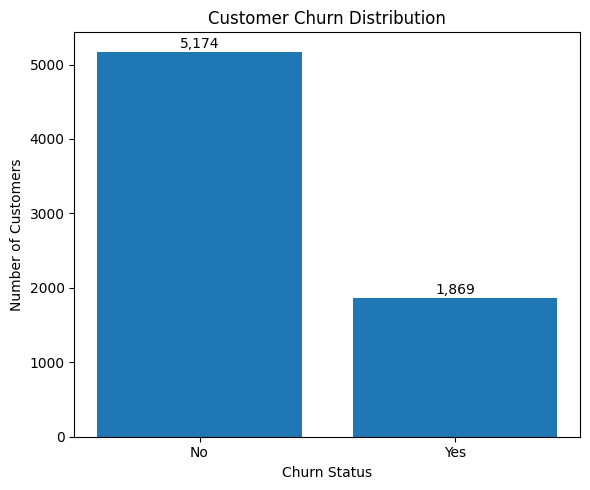

In [40]:
# Customer churn distribution
# Compare the number of customers who stayed with those who left.

churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"])

plt.figure(figsize=(6,5))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 50, f"{value:,}", ha="center")

plt.tight_layout()

plt.savefig(
    "churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

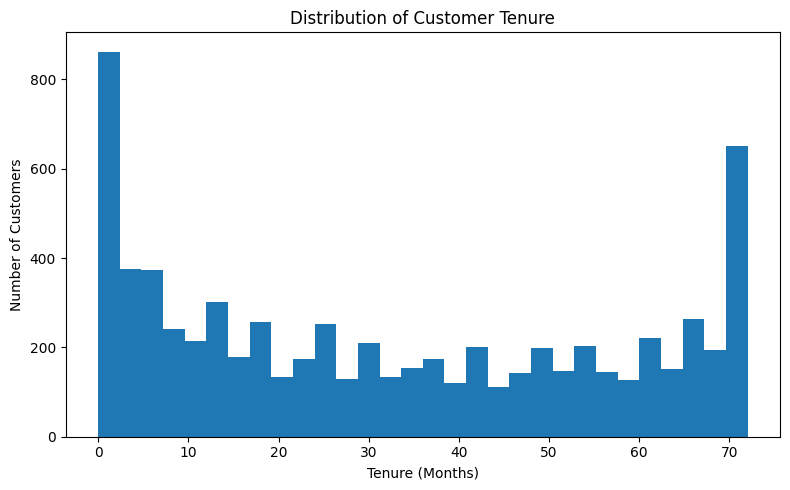

In [35]:
# Customer tenure distribution
# Understand how long customers have used the service

plt.figure(figsize=(8, 5))

plt.hist(df["tenure"], bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "tenure_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

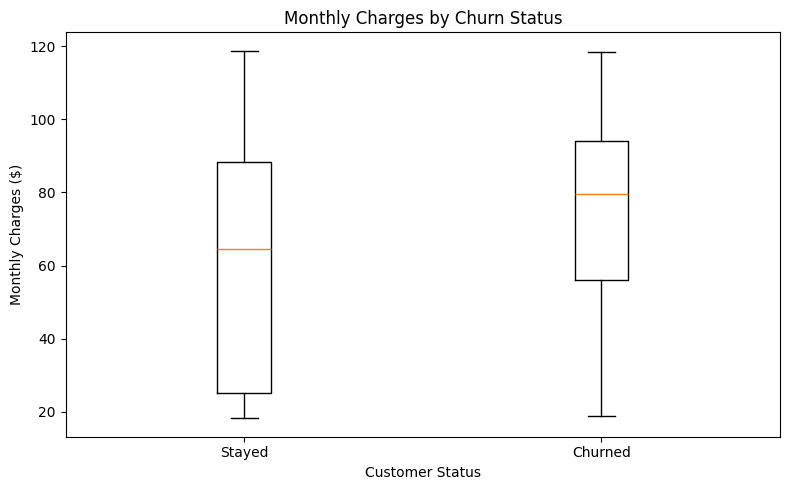

In [36]:
# Monthly charges by churn status
# Compare the monthly charges of customers who stayed and churned

stayed = df.loc[df["Churn"] == "No", "MonthlyCharges"]
churned = df.loc[df["Churn"] == "Yes", "MonthlyCharges"]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [stayed, churned],
    tick_labels=["Stayed", "Churned"]
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.savefig(
    "monthly_charges_by_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

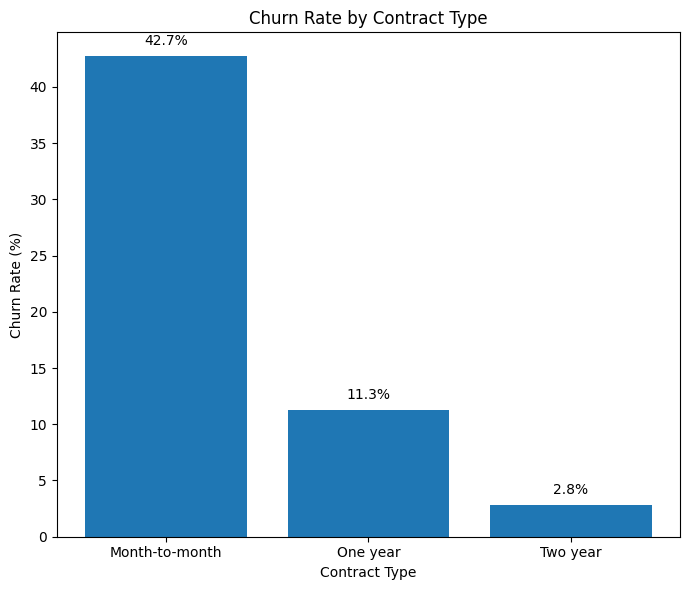

Churn rates by contract type:
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64


In [30]:
# Churn rate by contract type
# Identify differences in churn across contract types

contract_churn = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
)

contract_churn = contract_churn.reindex(
    ["Month-to-month", "One year", "Two year"]
)

churn_rates = contract_churn["Yes"]

plt.figure(figsize=(7,6))
plt.bar(churn_rates.index, churn_rates.values)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(churn_rates.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

print("Churn rates by contract type:")
print(churn_rates.round(2))

Correlation Matrix:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnBinary
SeniorCitizen,1.00,0.02,0.22,0.10,0.15
tenure,0.02,1.00,0.25,0.83,-0.35
MonthlyCharges,0.22,0.25,1.00,0.65,0.19
TotalCharges,0.10,0.83,0.65,1.00,-0.20
ChurnBinary,0.15,-0.35,0.19,-0.20,1.00


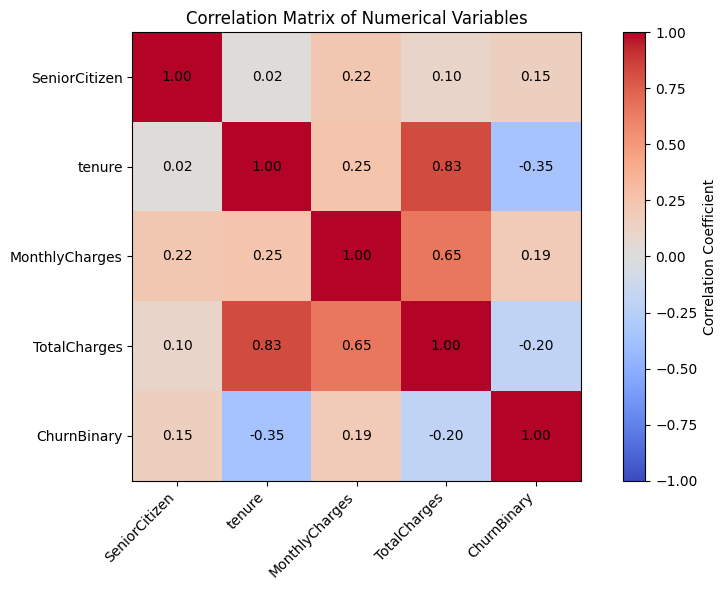

In [37]:
# Correlation matrix
# Explore numerical relationships between tenure, charges, senior-citizen status, and churn

numeric_columns = [                     # Numerical columns to analyze
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnBinary"
]

# Calculate correlations
correlation_matrix = df[numeric_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

plt.figure(figsize=(9, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation Coefficient")

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Matrix of Numerical Variables")

for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

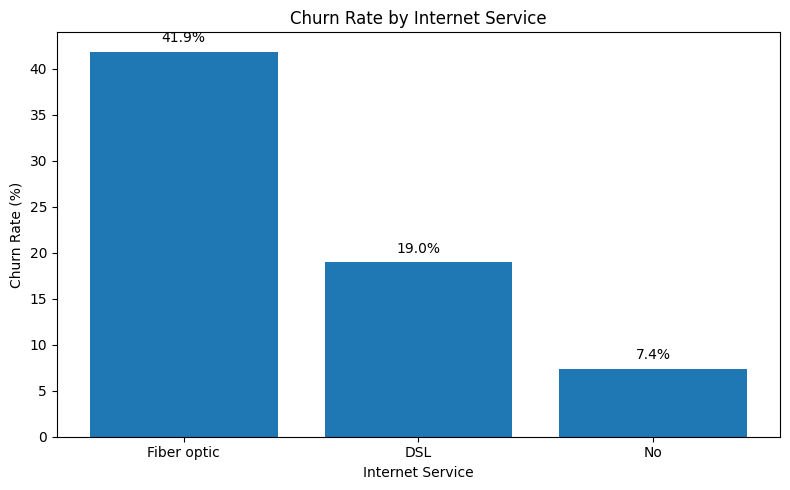

Churn rates by internet service:
InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Yes, dtype: float64


In [39]:
# Churn rate by internet service
# Compare churn rates among customers using different internet services

internet_churn = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
)

internet_churn_rate = internet_churn["Yes"].sort_values(
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    internet_churn_rate.index,
    internet_churn_rate.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(internet_churn_rate.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "churn_rate_by_internet_service.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("Churn rates by internet service:")
print(internet_churn_rate.round(2))